## 🧠 Building Expected Passes (xP) for Women’s Football

**Competition Focus:** Top 5 European Football Leagues 2015/16
**Purpose:** Build an Expected Passes (xP) model to quantify pass difficulty and decision-making  
**Methods:** Feature engineering, probabilistic modelling, model evaluation  
**Author:** [Victoria Friss de Kereki](https://www.linkedin.com/in/victoria-friss-de-kereki/)  
**Medium Articles:**  _TBC_

---

**Notebook first written:** `03/04/2026`  
**Last updated:** `03/04/2026`  

> This notebook develops an Expected Passes (xP) model tailored to top European men's football. The objective is to evaluate passing decisions beyond completion rates by estimating the likelihood of a pass being successfully completed given its context. The approach is modular and can be reused for different datasets, competitions, or extended into possession-value frameworks.
frameworks.


## Packages and configuration

In [1]:
from statsbombpy import sb
import pandas as pd
import numpy as np
from mplsoccer import VerticalPitch,Pitch
from highlight_text import ax_text, fig_text
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
import seaborn as sns
import pprint
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

import warnings
warnings.filterwarnings("ignore", message="credentials were not supplied")

## Load Competiton, Match, and Event Data from statsbombpy

In [17]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Call statsbomb API to get all free competitions, then check Women's comps
free_comps = sb.competitions()
men_comps = free_comps[free_comps['competition_gender'] == 'male']
men_comps

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
0,9,281,Germany,1. Bundesliga,male,False,False,2023/2024,2024-09-28T20:46:38.893391,2025-07-06T04:26:07.636270,2025-07-06T04:26:07.636270,2024-09-28T20:46:38.893391
1,9,27,Germany,1. Bundesliga,male,False,False,2015/2016,2024-05-19T11:11:14.192381,None,None,2024-05-19T11:11:14.192381
2,1267,107,Africa,African Cup of Nations,male,False,True,2023,2024-09-28T01:57:35.846538,None,None,2024-09-28T01:57:35.846538
3,16,4,Europe,Champions League,male,False,False,2018/2019,2025-05-08T15:10:50.835274,2021-06-13T16:17:31.694,None,2025-05-08T15:10:50.835274
4,16,1,Europe,Champions League,male,False,False,2017/2018,2024-02-13T02:35:28.134882,2021-06-13T16:17:31.694,None,2024-02-13T02:35:28.134882
...,...,...,...,...,...,...,...,...,...,...,...,...
66,12,27,Italy,Serie A,male,False,False,2015/2016,2025-07-21T05:01:00.434081,None,None,2025-07-21T05:01:00.434081
67,12,86,Italy,Serie A,male,False,False,1986/1987,2023-06-18T01:55:53.343752,None,None,2023-06-18T01:55:53.343752
68,55,282,Europe,UEFA Euro,male,False,True,2024,2024-09-28T16:51:20.698794,2025-03-24T14:12:30.785094,2025-03-24T14:12:30.785094,2024-09-28T16:51:20.698794
69,55,43,Europe,UEFA Euro,male,False,True,2020,2024-07-31T12:29:15.702309,2024-07-31T12:30:57.587087,2024-07-31T12:30:57.587087,2024-07-31T12:29:15.702309


In [18]:
# Prepare list to store match counts
match_counts = []

# Loop over each competition_id + season_id
for comp_id, season_id in zip(men_comps['competition_id'], men_comps['season_id']):
    # Count actual matches
    try:
        matches = sb.matches(competition_id=comp_id, season_id=season_id)
        matches_count = len(matches)
    except:
        matches_count = 0

    match_counts.append({
        'competition_id': comp_id,
        'season_id': season_id,
        'matches_count': matches_count
    })

# Convert to DataFrame
match_counts_df = pd.DataFrame(match_counts)

# Join metadata from men_comps
metadata_cols = ['competition_id', 'season_id', 'competition_name', 'season_name',
                 'match_updated', 'match_updated_360', 'match_available_360', 'match_available']
match_counts_df = match_counts_df.merge(men_comps[metadata_cols], on=['competition_id', 'season_id'], how='left')

# Sort by actual matches
match_counts_df.sort_values('matches_count', ascending=False, inplace=True)
match_counts_df.reset_index(drop=True, inplace=True)

In [19]:
match_counts_df[['competition_id', 'competition_name', 'season_id', 'season_name',
                 'matches_count', 'match_updated', 'match_updated_360',
                 'match_available_360', 'match_available']].head(10)

,competition_id,competition_name,season_id,season_name,matches_count,match_updated,match_updated_360,match_available_360,match_available
0,12,Serie A,27,2015/2016,380,2025-07-21T05:01:00.434081,None,None,2025-07-21T05:01:00.434081
1,2,Premier League,27,2015/2016,380,2025-04-23T14:36:29.347042,2021-06-13T16:17:31.694,None,2025-04-23T14:36:29.347042
2,11,La Liga,27,2015/2016,380,2025-04-23T13:59:22.835792,2021-06-13T16:17:31.694,None,2025-04-23T13:59:22.835792
3,7,Ligue 1,27,2015/2016,377,2024-12-16T08:48:23.066123,None,None,2024-12-16T08:48:23.066123
4,9,1. Bundesliga,27,2015/2016,306,2024-05-19T11:11:14.192381,None,None,2024-05-19T11:11:14.192381
5,1238,Indian Super league,108,2021/2022,115,2024-09-29T17:46:01.175308,None,None,2024-09-29T17:46:01.175308
6,43,FIFA World Cup,3,2018,64,2024-06-12T07:38:19.345758,2021-06-13T16:17:31.694,None,2024-06-12T07:38:19.345758
7,43,FIFA World Cup,106,2022,64,2024-12-16T10:15:11.055845,2024-12-16T10:21:13.710934,2024-12-16T10:21:13.710934,2024-12-16T10:15:11.055845
8,1267,African Cup of Nations,107,2023,52,2024-09-28T01:57:35.846538,None,None,2024-09-28T01:57:35.846538
9,55,UEFA Euro,43,2020,51,2024-07-31T12:29:15.702309,2024-07-31T12:30:57.587087,2024-07-31T12:30:57.587087,2024-07-31T12:29:15.702309


## All matches in Top 5 2015/16

In [20]:
leagues = [
    (12, 27),  # Serie A
    (2, 27),   # Premier League
    (11, 27),  # La Liga
    (7, 27),   # Ligue 1
    (9, 27)    # Bundesliga
]

all_matches = []

for comp_id, season_id in leagues:
    matches = sb.matches(
        competition_id=comp_id,
        season_id=season_id
    )
    
    # recommended: keep league identifier for later analysis
    matches["competition_id"] = comp_id
    
    all_matches.append(matches)

matches_df = pd.concat(all_matches, ignore_index=True)

In [21]:
len(matches_df)

1823

## All events, then keep passes only

In [22]:
import pandas as pd
from statsbombpy import sb
from pathlib import Path
from tqdm import tqdm  # progress bar

# Cache folder
CACHE_DIR = Path("statsbomb_cache/events_15_16")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

def load_events(match_id):
    """Load events for a match, using cache if available."""
    cache_file = CACHE_DIR / f"{match_id}.parquet"

    if cache_file.exists():
        return pd.read_parquet(cache_file)

    events = sb.events(match_id=match_id)
    events.to_parquet(cache_file)
    return events

In [25]:
from tqdm import tqdm

all_passes = []

for match_id in tqdm(matches_df["match_id"], desc="Extracting passes"):
    events = load_events(match_id)
    passes = events[events["type"] == "Pass"].copy()
    passes["match_id"] = match_id
    all_passes.append(passes)

passes_df = pd.concat(all_passes, ignore_index=True)

Extracting passes: 100%|██████████| 1823/1823 [00:36<00:00, 49.43it/s]


In [26]:
len(passes_df)

1777412

In [29]:
passes_clean = passes_df.dropna(axis=1, how="all")
passes_clean.head()

,counterpress,duration,id,index,location,match_id,minute,off_camera,out,pass_aerial_won,pass_angle,pass_assisted_shot_id,pass_body_part,pass_cross,pass_cut_back,pass_end_location,pass_goal_assist,pass_height,pass_length,pass_miscommunication,pass_no_touch,pass_outcome,pass_outswinging,pass_recipient,pass_recipient_id,pass_shot_assist,pass_switch,pass_technique,pass_type,period,play_pattern,player,player_id,position,possession,possession_team,possession_team_id,related_events,second,team,team_id,timestamp,type,under_pressure,pass_deflected,pass_inswinging,pass_straight,pass_through_ball
0,None,0.462911,819a652e-ec2e-408b-9c40-253c2be88817,5,"[61.0, 40.1]",3879863,0,None,None,None,2.425849,None,Right Foot,None,None,"[58.7, 42.1]",None,Ground Pass,3.047950,None,None,None,None,Luca Cigarini,8420.0,None,None,None,Kick Off,1,From Kick Off,Marten de Roon,6994.0,Left Defensive Midfield,2,Atalanta,228,[48c2d1ac-974b-49ae-ad53-d67d7d4964ed],0,Atalanta,228,00:00:00.556,Pass,None,NaN,NaN,NaN,NaN
1,None,1.485047,3f4a5604-9133-4782-92ce-3e09dcd39a1e,8,"[57.6, 42.1]",3879863,0,None,None,None,2.949424,None,Right Foot,None,None,"[35.5, 46.4]",None,Ground Pass,22.514440,None,None,None,None,Andrea Masiello,6992.0,None,None,None,None,1,From Kick Off,Luca Cigarini,8420.0,Right Defensive Midfield,2,Atalanta,228,[86364818-6ea7-48c7-9b6a-4c31e98c8a88],1,Atalanta,228,00:00:01.424,Pass,None,NaN,NaN,NaN,NaN
2,None,2.245250,8a442c77-0c85-4679-8249-6c76a7efca08,11,"[37.3, 46.2]",3879863,0,None,None,None,-0.722979,None,Right Foot,None,None,"[78.1, 10.2]",None,High Pass,54.411762,None,None,Incomplete,None,Jasmin Kurtič,6941.0,None,None,None,None,1,From Kick Off,Andrea Masiello,6992.0,Right Center Back,2,Atalanta,228,"[3ef041a3-3b8e-47d2-9e1d-a2d3d7e0cf31, 7769022...",3,Atalanta,228,00:00:03.925,Pass,None,NaN,NaN,NaN,NaN
3,None,2.842875,77690229-6f19-48d7-b712-27c6768792f1,13,"[42.0, 69.9]",3879863,0,None,None,None,-1.230292,None,Head,None,None,"[52.7, 39.7]",None,High Pass,32.039505,None,None,None,None,Emil Hallfreðsson,5512.0,None,None,None,Interception,1,From Kick Off,Silvan Widmer,7796.0,Right Wing Back,2,Atalanta,228,"[569e7e43-1151-4a02-8708-3e3b67c7a746, 8a442c7...",6,Udinese,230,00:00:06.170,Pass,None,NaN,NaN,NaN,NaN
4,None,1.385082,f703f951-6812-4bd1-ac4c-8fbe4717b137,15,"[53.3, 39.7]",3879863,0,None,None,None,-1.458369,None,Head,None,None,"[54.0, 33.5]",None,High Pass,6.239391,None,None,Incomplete,None,None,NaN,None,None,None,None,1,From Kick Off,Emil Hallfreðsson,5512.0,Left Center Midfield,2,Atalanta,228,[4f307b3e-43e6-4f88-bbd9-c93872eaf92b],9,Udinese,230,00:00:09.013,Pass,None,NaN,NaN,NaN,NaN


In [30]:
len(passes_clean)

1777412

In [31]:
passes_clean["play_pattern"].unique()

array(['From Kick Off', 'From Throw In', 'Regular Play', 'From Corner',
       'From Goal Kick', 'From Free Kick', 'From Keeper', 'Other',
       'From Counter'], dtype=object)

In [32]:
passes_clean.to_csv("Datasets/passes_mens_europe_15_16.csv", index=False)

In [87]:
passes_clean = pd.read_csv("Datasets/passes_mens_europe_15_16.csv")

## Data Inspection and Cleaning

In [88]:
# Filter rows where all columns are NaN
all_nan_rows = passes_clean[passes_clean.isna().all(axis=1)]

# Show all columns for these rows
pd.set_option("display.max_columns", None)
print(all_nan_rows)

# Optional: count how many there are
print(f"Number of rows where all values are NaN: {len(all_nan_rows)}")

Empty DataFrame
Columns: [counterpress, duration, id, index, location, match_id, minute, off_camera, out, pass_aerial_won, pass_angle, pass_assisted_shot_id, pass_body_part, pass_cross, pass_cut_back, pass_end_location, pass_goal_assist, pass_height, pass_length, pass_miscommunication, pass_no_touch, pass_outcome, pass_outswinging, pass_recipient, pass_recipient_id, pass_shot_assist, pass_switch, pass_technique, pass_type, period, play_pattern, player, player_id, position, possession, possession_team, possession_team_id, related_events, second, team, team_id, timestamp, type, under_pressure, pass_deflected, pass_inswinging, pass_straight, pass_through_ball]
Index: []
Number of rows where all values are NaN: 0


In [89]:
def extract_coords(coord_col):
    # Convert everything to string first, then split
    x = pd.to_numeric(coord_col.astype(str).str.strip("[]").str.split().str[0], errors="coerce")
    y = pd.to_numeric(coord_col.astype(str).str.strip("[]").str.split().str[1], errors="coerce")
    return x, y

# Apply to location columns
passes_clean["start_x"], passes_clean["start_y"] = extract_coords(passes_clean["location"])
passes_clean["end_x"], passes_clean["end_y"] = extract_coords(passes_clean["pass_end_location"])

# Check missing values
cols = ["start_x", "start_y", "end_x", "end_y"]
print(passes_clean[cols].isna().sum())

start_x    0
start_y    0
end_x      0
end_y      0
dtype: int64


In [90]:
len(passes_clean)

1777412

In [91]:
pd.crosstab(
    passes_clean["pass_type"], 
    passes_clean["play_pattern"], 
    dropna=False
)

play_pattern,From Corner,From Counter,From Free Kick,From Goal Kick,From Keeper,From Kick Off,From Throw In,Other,Regular Play
pass_type,,,,,,,,,
Corner,18391,0,0,0,0,0,0,0,0
Free Kick,0,0,54541,0,0,0,0,0,0
Goal Kick,0,0,0,30077,0,0,0,0,0
Interception,205,344,1389,1023,250,236,3071,9,8914
Kick Off,0,0,0,0,24,8409,0,0,0
Recovery,6985,2790,22631,19358,3979,3747,33697,516,90227
Throw-in,0,0,0,0,0,0,84783,0,0
NaN,33552,9315,200578,90101,46078,46420,314476,2286,639010


In [92]:
passes_clean["pass_outcome"].value_counts(dropna=False)

pass_outcome
NaN                 1360985
Incomplete           358811
Out                   34957
Unknown               12074
Pass Offside           7640
Injury Clearance       2945
Name: count, dtype: int64

In [93]:
# 1️⃣ Replace NaN with "Complete"
passes_clean["pass_outcome"] = passes_clean["pass_outcome"].fillna("Complete")

# 2️⃣ Quick check after replacement
passes_clean["pass_outcome"].value_counts()

pass_outcome
Complete            1360985
Incomplete           358811
Out                   34957
Unknown               12074
Pass Offside           7640
Injury Clearance       2945
Name: count, dtype: int64

In [94]:
# Percentage of Unknown passes
total_passes = len(passes_clean)
unknown_passes = passes_clean[passes_clean["pass_outcome"] == "Unknown"]
percent_unknown = len(unknown_passes) / total_passes * 100

print(f"Unknown passes: {len(unknown_passes)} / {total_passes} ({percent_unknown:.2f}%)")

# Show all columns for inspection
with pd.option_context("display.max_columns", None):
    display(unknown_passes.head())

Unknown passes: 12074 / 1777412 (0.68%)


,counterpress,duration,id,index,location,match_id,minute,off_camera,out,pass_aerial_won,pass_angle,pass_assisted_shot_id,pass_body_part,pass_cross,pass_cut_back,pass_end_location,pass_goal_assist,pass_height,pass_length,pass_miscommunication,pass_no_touch,pass_outcome,pass_outswinging,pass_recipient,pass_recipient_id,pass_shot_assist,pass_switch,pass_technique,pass_type,period,play_pattern,player,player_id,position,possession,possession_team,possession_team_id,related_events,second,team,team_id,timestamp,type,under_pressure,pass_deflected,pass_inswinging,pass_straight,pass_through_ball,start_x,start_y,end_x,end_y
599,NaN,1.381080,06e46eec-90dc-458f-9d2f-2cb4f8dbec17,2061,[53.7 0.1],3879863,51,NaN,NaN,NaN,0.165149,NaN,NaN,NaN,NaN,[68.1 2.5],NaN,High Pass,14.598630,NaN,NaN,Unknown,NaN,Marco Borriello,8871.0,NaN,NaN,NaN,Throw-in,2,From Throw In,Davide Brivio,31231.0,Left Back,98,Atalanta,228,['0248d832-a0da-43a6-b3f7-e7265c1a9a39'],52,Atalanta,228,00:06:52.325,Pass,NaN,NaN,NaN,NaN,NaN,53.7,0.1,68.1,2.5
717,NaN,1.067991,02c82329-b725-488e-b109-b5b5d1b5ef47,2454,[55.9 48.1],3879863,60,NaN,NaN,NaN,0.352706,NaN,Right Foot,NaN,NaN,[72.2 54.1],NaN,Ground Pass,17.369226,NaN,NaN,Unknown,NaN,Alessandro Diamanti,19847.0,NaN,NaN,NaN,NaN,2,From Free Kick,Luca Cigarini,8420.0,Right Defensive Midfield,112,Atalanta,228,['3f1b6c6a-7bab-435b-8d90-becd79343763'],23,Atalanta,228,00:15:23.735,Pass,NaN,NaN,NaN,NaN,NaN,55.9,48.1,72.2,54.1
725,NaN,0.951462,6b7c17f0-c55d-4e06-87ab-28e2dc261406,2487,[98.1 7. ],3879863,61,NaN,NaN,NaN,1.090344,NaN,Right Foot,True,NaN,[110.4 30.6],NaN,High Pass,26.612967,NaN,NaN,Unknown,NaN,Marco Borriello,8871.0,NaN,NaN,NaN,NaN,2,From Throw In,Jasmin Kurtič,6941.0,Left Wing,114,Atalanta,228,['a12cb5dc-04a6-466c-8e38-becd786e4ab4'],2,Atalanta,228,00:16:02.416,Pass,NaN,NaN,NaN,NaN,NaN,98.1,7.0,110.4,30.6
740,NaN,2.553669,a58e58c3-c5e8-46e4-aa89-c1ea5d49b03e,2536,[64.6 6.8],3879863,62,NaN,NaN,NaN,-0.106434,NaN,Left Foot,NaN,NaN,[88. 4.3],NaN,High Pass,23.533169,NaN,NaN,Unknown,NaN,Marco Borriello,8871.0,NaN,NaN,NaN,NaN,2,Regular Play,Davide Brivio,31231.0,Left Back,116,Atalanta,228,['03b14d0c-17a4-4c1c-88f9-295e86de5328'],21,Atalanta,228,00:17:21.358,Pass,NaN,NaN,NaN,NaN,NaN,64.6,6.8,88.0,4.3
780,NaN,3.027645,0d9a0f59-1d9d-4ec0-bc50-3e2adb1fe0c3,2671,[5.2 4. ],3879863,66,NaN,NaN,NaN,0.368405,NaN,Left Foot,NaN,NaN,[59.6 25. ],NaN,High Pass,58.312607,NaN,NaN,Unknown,NaN,Marco Borriello,8871.0,NaN,NaN,NaN,NaN,2,From Counter,Davide Brivio,31231.0,Left Back,126,Atalanta,228,['dc8db45d-3b5b-4386-8d68-009067f38a7e'],8,Atalanta,228,00:21:08.133,Pass,NaN,NaN,NaN,NaN,NaN,5.2,4.0,59.6,25.0


In [95]:
# Count of Unknown passes per match
unknown_per_match = unknown_passes["match_id"].value_counts()

# Quick summary
print("Number of matches with Unknown passes:", unknown_per_match.shape[0])
print("Top matches with most Unknown passes:")
print(unknown_per_match.head(10))

# Optional: percentage of Unknown passes per match
unknown_percent_per_match = unknown_per_match / passes_clean["match_id"].value_counts() * 100
unknown_percent_per_match.sort_values(ascending=False).head(10)

Number of matches with Unknown passes: 1814
Top matches with most Unknown passes:
match_id
3890262    23
3890300    21
3879629    21
3890555    18
3879826    18
3825858    18
3829467    18
3890272    17
3901227    17
3890515    17
Name: count, dtype: int64


match_id
3890262    3.422619
3890300    2.800000
3879629    2.573529
3900529    2.322404
3890525    2.231520
3879826    2.216749
3900535    2.176697
3890459    2.173913
3825858    2.153110
3890272    2.135678
Name: count, dtype: float64

In [96]:
# Remove all Unknown passes
passes_clean = passes_clean[passes_clean["pass_outcome"] != "Unknown"].copy()

# Quick check
passes_clean["pass_outcome"].value_counts(dropna=False)

pass_outcome
Complete            1360985
Incomplete           358811
Out                   34957
Pass Offside           7640
Injury Clearance       2945
Name: count, dtype: int64

In [97]:
# Remove Injury Clearance passes
passes_clean = passes_clean[passes_clean["pass_outcome"] != "Injury Clearance"].copy()

# Quick check
passes_clean["pass_outcome"].value_counts(dropna=False)

pass_outcome
Complete        1360985
Incomplete       358811
Out               34957
Pass Offside       7640
Name: count, dtype: int64

In [98]:
# Create Outcome column: 1 if Complete, 0 otherwise
passes_clean["Outcome"] = (passes_clean["pass_outcome"] == "Complete").astype(int)

# Quick check
passes_clean[["pass_outcome", "Outcome"]].head(5)

,pass_outcome,Outcome
0,Complete,1
1,Complete,1
2,Incomplete,0
3,Complete,1
4,Incomplete,0


In [99]:
PITCH_LENGTH = 120
PITCH_WIDTH = 80

# Start location checks
start_outside = passes_clean[
    (passes_clean["start_x"] <= 0) | (passes_clean["start_x"] > PITCH_LENGTH) |
    (passes_clean["start_y"] <= 0) | (passes_clean["start_y"] > PITCH_WIDTH)
]

# End (reception) location checks
end_outside = passes_clean[
    (passes_clean["end_x"] <= 0) | (passes_clean["end_x"] > PITCH_LENGTH) |
    (passes_clean["end_y"] <= 0) | (passes_clean["end_y"] > PITCH_WIDTH)
]

print(f"Start locations outside pitch: {len(start_outside)}")
print(f"End locations outside pitch: {len(end_outside)}")

Start locations outside pitch: 6
End locations outside pitch: 15


In [100]:
# Passes with start locations outside the pitch
print("Passes with start locations outside pitch:")
display(start_outside.head())

# Passes with end locations outside the pitch
print("Passes with end locations outside pitch:")
display(end_outside.head())

Passes with start locations outside pitch:


,counterpress,duration,id,index,location,match_id,minute,off_camera,out,pass_aerial_won,pass_angle,pass_assisted_shot_id,pass_body_part,pass_cross,pass_cut_back,pass_end_location,pass_goal_assist,pass_height,pass_length,pass_miscommunication,pass_no_touch,pass_outcome,pass_outswinging,pass_recipient,pass_recipient_id,pass_shot_assist,pass_switch,pass_technique,pass_type,period,play_pattern,player,player_id,position,possession,possession_team,possession_team_id,related_events,second,team,team_id,timestamp,type,under_pressure,pass_deflected,pass_inswinging,pass_straight,pass_through_ball,start_x,start_y,end_x,end_y,Outcome
305374,NaN,3.937426,8537f75f-a29a-415a-9daf-bbf0a8451f3f,1836,[120.3 80. ],3879580,48,NaN,NaN,NaN,-1.576749,NaN,Left Foot,NaN,NaN,[120. 29.6],NaN,High Pass,50.400894,NaN,NaN,Out,NaN,NaN,NaN,NaN,True,Inswinging,Corner,2,From Corner,Paulo Bruno Exequiel Dybala,5743.0,Right Center Forward,109,Juventus,224,NaN,1,Juventus,224,00:03:01.542,Pass,NaN,NaN,True,NaN,NaN,120.3,80.0,120.0,29.6,0
378657,NaN,2.447160,515d009d-4842-4b51-8e98-91ca954e74af,813,[120.7 0.7],3754041,17,NaN,NaN,NaN,1.663247,NaN,Right Foot,NaN,NaN,[116.5 46. ],NaN,High Pass,45.494286,NaN,NaN,Incomplete,NaN,NaN,NaN,NaN,True,Straight,Corner,1,From Corner,Ashley Westwood,3583.0,Right Center Midfield,48,Aston Villa,59,['449b518e-4472-4ef8-a89d-e50da665e896'],43,Aston Villa,59,00:17:43.379,Pass,NaN,NaN,NaN,True,NaN,120.7,0.7,116.5,46.0,0
605652,NaN,0.859729,157e85a2-dd6e-4bcc-bbd1-21013fbefb0e,906,[120.9 2.8],3754087,20,NaN,NaN,NaN,2.291955,NaN,Right Foot,NaN,NaN,[112.9 11.9],NaN,Ground Pass,12.116518,NaN,NaN,Complete,NaN,Philippe Coutinho Correia,3501.0,NaN,NaN,NaN,Corner,1,From Corner,James Philip Milner,3473.0,Right Wing,46,Liverpool,24,['db5c8e5e-d9f3-4b59-9797-b9d2562875c1'],33,Liverpool,24,00:20:33.996,Pass,NaN,NaN,NaN,NaN,NaN,120.9,2.8,112.9,11.9,1
1087627,NaN,4.152200,f554cda6-34f9-4d7f-82fe-09c1c2c53d81,1980,[120.2 23.8],266961,48,NaN,NaN,NaN,1.671321,NaN,Left Foot,NaN,NaN,[116.7 58.5],NaN,High Pass,34.876070,NaN,NaN,Incomplete,NaN,Sandro Ramírez Castillo,3508.0,NaN,NaN,NaN,NaN,2,From Throw In,Andrés Iniesta Luján,5216.0,Left Center Midfield,96,Barcelona,217,['34b0df16-1636-46e4-828a-0f487da4727e'\n '445...,54,Barcelona,217,00:03:54.555,Pass,True,NaN,NaN,NaN,NaN,120.2,23.8,116.7,58.5,0
1295761,NaN,0.939290,12ccbccd-e075-4aba-bac4-75381b5cae22,2034,[120.4 80. ],3900518,47,NaN,NaN,NaN,-2.458401,NaN,Left Foot,NaN,NaN,[116.1 76.5],NaN,Ground Pass,5.544366,NaN,NaN,Complete,NaN,Billy Ketkeophomphone,4441.0,NaN,NaN,NaN,Corner,1,From Corner,Thomas Mangani,3185.0,Left Center Midfield,83,Angers,145,['f53ab04c-f3c7-43d2-96a6-5582eceb86d1'],40,Angers,145,00:47:40.368,Pass,NaN,NaN,NaN,NaN,NaN,120.4,80.0,116.1,76.5,1


Passes with end locations outside pitch:


,counterpress,duration,id,index,location,match_id,minute,off_camera,out,pass_aerial_won,pass_angle,pass_assisted_shot_id,pass_body_part,pass_cross,pass_cut_back,pass_end_location,pass_goal_assist,pass_height,pass_length,pass_miscommunication,pass_no_touch,pass_outcome,pass_outswinging,pass_recipient,pass_recipient_id,pass_shot_assist,pass_switch,pass_technique,pass_type,period,play_pattern,player,player_id,position,possession,possession_team,possession_team_id,related_events,second,team,team_id,timestamp,type,under_pressure,pass_deflected,pass_inswinging,pass_straight,pass_through_ball,start_x,start_y,end_x,end_y,Outcome
1087097,NaN,0.7722,85e337e3-39d6-4250-928d-a30c05f097b9,105,[111.2 14.4],266961,2,NaN,NaN,NaN,1.222326,NaN,Left Foot,True,NaN,[120.9 41.1],NaN,High Pass,28.407393,NaN,NaN,Out,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,From Keeper,Lucas Pérez Martínez,6732.0,Left Center Forward,5,RC Deportivo La Coruña,219,NaN,15,RC Deportivo La Coruña,219,00:02:15.530,Pass,NaN,NaN,NaN,NaN,NaN,111.2,14.4,120.9,41.1,0
1087364,NaN,4.0401,5617e24c-0655-48b5-ba84-6c23ce394325,1020,[64.4 5.2],266961,25,NaN,NaN,NaN,0.142892,NaN,Right Foot,NaN,NaN,[120.7 13.3],NaN,High Pass,56.879696,NaN,NaN,Out,NaN,Lucas Pérez Martínez,6732.0,NaN,NaN,NaN,Free Kick,1,From Free Kick,Sidnei Rechel da Silva Júnior,6777.0,Left Center Back,50,RC Deportivo La Coruña,219,['b6e8d4e1-83c4-49cc-b318-e7b07438150f'],57,RC Deportivo La Coruña,219,00:25:57.055,Pass,NaN,NaN,NaN,NaN,NaN,64.4,5.2,120.7,13.3,0
1087466,NaN,4.9897,28dc8dbd-ca06-40e5-91d9-df6ac59c04e0,1411,[ 7. 37.],266961,35,NaN,NaN,NaN,0.620869,NaN,Left Foot,NaN,NaN,[68.1 80.7],NaN,Low Pass,75.119240,NaN,NaN,Out,NaN,Laureano Sanabria Ruiz,23800.0,NaN,True,NaN,Goal Kick,1,From Goal Kick,Germán Darío Lux,27305.0,Goalkeeper,69,RC Deportivo La Coruña,219,['9027c54c-c67d-4b69-8179-7e4771729541'],3,RC Deportivo La Coruña,219,00:35:03.963,Pass,NaN,NaN,NaN,NaN,NaN,7.0,37.0,68.1,80.7,0
1087994,NaN,2.1944,6452df11-b6f7-4dc1-9ab7-e7e90cee8096,3331,[109.1 56.3],266961,78,NaN,NaN,NaN,-1.105433,NaN,Right Foot,NaN,NaN,[120.8 33. ],NaN,Ground Pass,26.072592,NaN,NaN,Out,NaN,Lionel Andrés Messi Cuccittini,5503.0,NaN,NaN,NaN,NaN,2,From Counter,Luis Alberto Suárez Díaz,5246.0,Center Forward,150,Barcelona,217,['4f396397-47d0-4491-8810-95666c16e0a8'\n '8fc...,39,Barcelona,217,00:33:39.569,Pass,True,NaN,NaN,NaN,NaN,109.1,56.3,120.8,33.0,0
1088067,NaN,3.3384,b86912bc-55ad-4321-9233-8c17a700a15b,3643,[96.7 52. ],266961,87,NaN,NaN,NaN,-0.846227,NaN,Left Foot,NaN,NaN,[120.6 25. ],NaN,High Pass,36.058426,NaN,NaN,Out,NaN,Gerard Piqué Bernabéu,5213.0,NaN,NaN,NaN,NaN,2,From Throw In,Daniel Alves da Silva,4324.0,Right Back,165,Barcelona,217,['1d3a3f10-6d34-4be9-b599-1194db7f4b12'],12,Barcelona,217,00:42:12.843,Pass,NaN,NaN,NaN,NaN,NaN,96.7,52.0,120.6,25.0,0


In [101]:
# Define pitch limits
PITCH_LENGTH = 120
PITCH_WIDTH = 80

# Fix start coordinates
passes_clean.loc[passes_clean["start_x"] > PITCH_LENGTH, "start_x"] = PITCH_LENGTH
passes_clean.loc[passes_clean["start_x"] < 0, "start_x"] = 0

passes_clean.loc[passes_clean["start_y"] > PITCH_WIDTH, "start_y"] = PITCH_WIDTH
passes_clean.loc[passes_clean["start_y"] < 0, "start_y"] = 0

# Fix end coordinates
passes_clean.loc[passes_clean["end_x"] > PITCH_LENGTH, "end_x"] = PITCH_LENGTH
passes_clean.loc[passes_clean["end_x"] < 0, "end_x"] = 0

passes_clean.loc[passes_clean["end_y"] > PITCH_WIDTH, "end_y"] = PITCH_WIDTH
passes_clean.loc[passes_clean["end_y"] < 0, "end_y"] = 0

# Quick check for remaining out-of-bounds
start_outside = passes_clean[
    (passes_clean["start_x"] < 0) | (passes_clean["start_x"] > PITCH_LENGTH) |
    (passes_clean["start_y"] < 0) | (passes_clean["start_y"] > PITCH_WIDTH)
]
end_outside = passes_clean[
    (passes_clean["end_x"] < 0) | (passes_clean["end_x"] > PITCH_LENGTH) |
    (passes_clean["end_y"] < 0) | (passes_clean["end_y"] > PITCH_WIDTH)
]

print(f"Start locations outside pitch after adjustment: {len(start_outside)}")
print(f"End locations outside pitch after adjustment: {len(end_outside)}")

Start locations outside pitch after adjustment: 0
End locations outside pitch after adjustment: 0


## Pass start position

In [102]:
# Define pitch bins (10x10 squares grid)
x_bins = np.linspace(0, 120, 13)
y_bins = np.linspace(0, 80, 9)

passes_clean["start_x_zone"] = pd.cut(df["start_x"], bins=x_bins, labels=False)
passes_clean["start_y_zone"] = pd.cut(df["start_y"], bins=y_bins, labels=False)

In [103]:
passes_clean.head()

,counterpress,duration,id,index,location,match_id,minute,off_camera,out,pass_aerial_won,pass_angle,pass_assisted_shot_id,pass_body_part,pass_cross,pass_cut_back,pass_end_location,pass_goal_assist,pass_height,pass_length,pass_miscommunication,pass_no_touch,pass_outcome,pass_outswinging,pass_recipient,pass_recipient_id,pass_shot_assist,pass_switch,pass_technique,pass_type,period,play_pattern,player,player_id,position,possession,possession_team,possession_team_id,related_events,second,team,team_id,timestamp,type,under_pressure,pass_deflected,pass_inswinging,pass_straight,pass_through_ball,start_x,start_y,end_x,end_y,Outcome,start_x_zone,start_y_zone
0,NaN,0.462911,819a652e-ec2e-408b-9c40-253c2be88817,5,[61. 40.1],3879863,0,NaN,NaN,NaN,2.425849,NaN,Right Foot,NaN,NaN,[58.7 42.1],NaN,Ground Pass,3.047950,NaN,NaN,Complete,NaN,Luca Cigarini,8420.0,NaN,NaN,NaN,Kick Off,1,From Kick Off,Marten de Roon,6994.0,Left Defensive Midfield,2,Atalanta,228,['48c2d1ac-974b-49ae-ad53-d67d7d4964ed'],0,Atalanta,228,00:00:00.556,Pass,NaN,NaN,NaN,NaN,NaN,61.0,40.1,58.7,42.1,1,6,4
1,NaN,1.485047,3f4a5604-9133-4782-92ce-3e09dcd39a1e,8,[57.6 42.1],3879863,0,NaN,NaN,NaN,2.949424,NaN,Right Foot,NaN,NaN,[35.5 46.4],NaN,Ground Pass,22.514440,NaN,NaN,Complete,NaN,Andrea Masiello,6992.0,NaN,NaN,NaN,NaN,1,From Kick Off,Luca Cigarini,8420.0,Right Defensive Midfield,2,Atalanta,228,['86364818-6ea7-48c7-9b6a-4c31e98c8a88'],1,Atalanta,228,00:00:01.424,Pass,NaN,NaN,NaN,NaN,NaN,57.6,42.1,35.5,46.4,1,5,4
2,NaN,2.245250,8a442c77-0c85-4679-8249-6c76a7efca08,11,[37.3 46.2],3879863,0,NaN,NaN,NaN,-0.722979,NaN,Right Foot,NaN,NaN,[78.1 10.2],NaN,High Pass,54.411762,NaN,NaN,Incomplete,NaN,Jasmin Kurtič,6941.0,NaN,NaN,NaN,NaN,1,From Kick Off,Andrea Masiello,6992.0,Right Center Back,2,Atalanta,228,['3ef041a3-3b8e-47d2-9e1d-a2d3d7e0cf31'\n '776...,3,Atalanta,228,00:00:03.925,Pass,NaN,NaN,NaN,NaN,NaN,37.3,46.2,78.1,10.2,0,3,4
3,NaN,2.842875,77690229-6f19-48d7-b712-27c6768792f1,13,[42. 69.9],3879863,0,NaN,NaN,NaN,-1.230292,NaN,Head,NaN,NaN,[52.7 39.7],NaN,High Pass,32.039505,NaN,NaN,Complete,NaN,Emil Hallfreðsson,5512.0,NaN,NaN,NaN,Interception,1,From Kick Off,Silvan Widmer,7796.0,Right Wing Back,2,Atalanta,228,['569e7e43-1151-4a02-8708-3e3b67c7a746'\n '8a4...,6,Udinese,230,00:00:06.170,Pass,NaN,NaN,NaN,NaN,NaN,42.0,69.9,52.7,39.7,1,4,6
4,NaN,1.385082,f703f951-6812-4bd1-ac4c-8fbe4717b137,15,[53.3 39.7],3879863,0,NaN,NaN,NaN,-1.458369,NaN,Head,NaN,NaN,[54. 33.5],NaN,High Pass,6.239391,NaN,NaN,Incomplete,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,From Kick Off,Emil Hallfreðsson,5512.0,Left Center Midfield,2,Atalanta,228,['4f307b3e-43e6-4f88-bbd9-c93872eaf92b'],9,Udinese,230,00:00:09.013,Pass,NaN,NaN,NaN,NaN,NaN,53.3,39.7,54.0,33.5,0,5,3


In [104]:
zone_stats_start = (
    passes_clean
    .groupby(["start_x_zone", "start_y_zone"])
    .agg(
        passes=("Outcome", "count"),           # total passes in the zone
        completion_rate=("Outcome", "mean")    # % of passes completed
    )
    .reset_index()
)

zone_stats_start.head()

,start_x_zone,start_y_zone,passes,completion_rate
0,0,0,4700,0.513191
1,0,1,3505,0.609415
2,0,2,4798,0.603376
3,0,3,24141,0.595791
4,0,4,26614,0.584054


In [105]:
# Find the minimum number of passes
min_passes = zone_stats_start["passes"].min()

# Filter zones with that minimum
zone_stats_start[zone_stats_start["passes"] == min_passes]

# Will keep them all as all zones have more than enough passes :)

,start_x_zone,start_y_zone,passes,completion_rate
92,11,4,652,0.521472


In [106]:
completion_grid_start = zone_stats_start.pivot(
    index="start_y_zone",
    columns="start_x_zone",
    values="completion_rate"
)

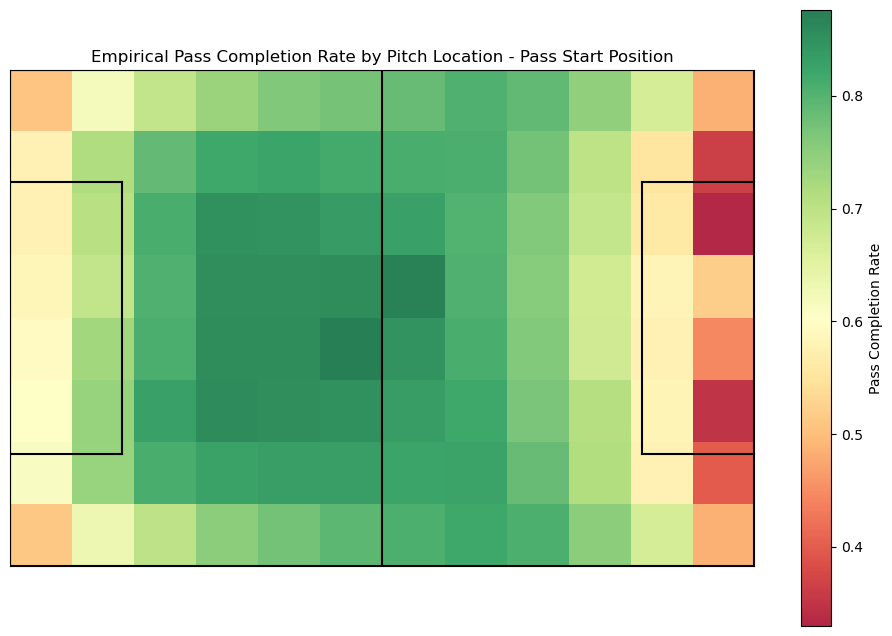

In [107]:
fig, ax = plt.subplots(figsize=(12, 8))

# Pitch outline. StatsBomb’s default pitch dimensions are 120x80
ax.plot([0, 120, 120, 0, 0], [0, 0, 80, 80, 0], color="black")
ax.plot([60, 60], [0, 80], color="black")

# Penalty areas
ax.plot([102, 120], [18, 18], color="black")
ax.plot([102, 102], [18, 62], color="black")
ax.plot([102, 120], [62, 62], color="black")

ax.plot([0, 18], [18, 18], color="black")
ax.plot([18, 18], [18, 62], color="black")
ax.plot([0, 18], [62, 62], color="black")

# Heatmap of completion rate
im = ax.imshow(
    completion_grid_start.values,
    extent=[0, 120, 0, 80],
    origin="lower",
    cmap="RdYlGn", #RedYellowGreen
    alpha=0.85
)

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Pass Completion Rate")

# Formatting
ax.set_title("Empirical Pass Completion Rate by Pitch Location - Pass Start Position")
ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect("equal")

plt.savefig("heatmap_start.png", dpi=300, bbox_inches="tight")

plt.show()

## Pass end position

In [108]:
# Define pitch bins (10-yard grid)
x_bins = np.linspace(0, 120, 13)
y_bins = np.linspace(0, 80, 9)

passes_clean["end_x_zone"] = pd.cut(df["end_x"], bins=x_bins, labels=False)
passes_clean["end_y_zone"] = pd.cut(df["end_y"], bins=y_bins, labels=False)

In [109]:
zone_stats_end = (
    passes_clean
    .groupby(["end_x_zone", "end_y_zone"])
    .agg(
        passes=("Outcome", "count"),           # total passes in the zone
        completion_rate=("Outcome", "mean")    # % of passes completed
    )
    .reset_index()
)

zone_stats_end.head()

,end_x_zone,end_y_zone,passes,completion_rate
0,0,0,1645,0.588450
1,0,1,1940,0.900000
2,0,2,3079,0.960702
3,0,3,7542,0.996022
4,0,4,8849,0.996271


In [110]:
completion_grid_end = zone_stats_end.pivot(
    index="end_y_zone",
    columns="end_x_zone",
    values="completion_rate"
)

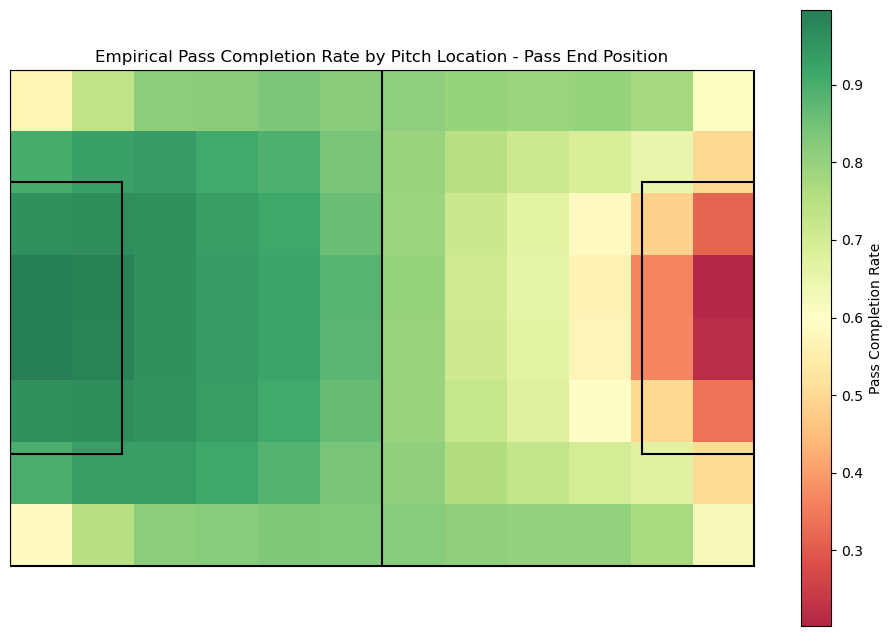

In [111]:
fig, ax = plt.subplots(figsize=(12, 8))

# Pitch outline
ax.plot([0, 120, 120, 0, 0], [0, 0, 80, 80, 0], color="black")
ax.plot([60, 60], [0, 80], color="black")

# Penalty areas
ax.plot([102, 120], [18, 18], color="black")
ax.plot([102, 102], [18, 62], color="black")
ax.plot([102, 120], [62, 62], color="black")

ax.plot([0, 18], [18, 18], color="black")
ax.plot([18, 18], [18, 62], color="black")
ax.plot([0, 18], [62, 62], color="black")

# Heatmap of completion rate
im = ax.imshow(
    completion_grid_end.values,
    extent=[0, 120, 0, 80],
    origin="lower",
    cmap="RdYlGn",
    alpha=0.85
)

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Pass Completion Rate")

# Formatting
ax.set_title("Empirical Pass Completion Rate by Pitch Location - Pass End Position")
ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect("equal")

plt.savefig("heatmap_end.png", dpi=300, bbox_inches="tight")

plt.show()

## Feature engineering

In [258]:
passes_clean["pass_type"] = passes_clean["pass_type"].fillna("Open Play")

In [262]:
passes_clean.loc[passes_clean["pass_type"] == "Throw-in", "pass_body_part"] = "Throw-in"

In [268]:
# Merge all feet and rare categories into Foot
passes_clean.loc[passes_clean["pass_body_part"].isin(
    ["Right Foot", "Left Foot", "Other", "Drop Kick", "Keeper Arm", "No Touch"]
), "pass_body_part"] = "Foot"

# Unknown body parts → Foot
passes_clean.loc[passes_clean["pass_body_part"].isna(), "pass_body_part"] = "Foot"

In [269]:
pd.crosstab(
    passes_clean["pass_body_part"],
    passes_clean["pass_type"],
    dropna=False
)

pass_type,Corner,Free Kick,Goal Kick,Interception,Kick Off,Open Play,Recovery,Throw-in
pass_body_part,,,,,,,,
Foot,17928,53597,29181,10574,8426,1346035,129724,0
Head,0,0,0,4752,0,26537,52155,0
Throw-in,0,0,0,0,0,0,0,83484


In [292]:
import pandas as pd
import numpy as np

def prepare_pass_features(df_passes):

    # -----------------------------------------------------
    # Copy dataframe to avoid modifying original dataset
    # -----------------------------------------------------
    df = df_passes.copy()

    # -----------------------------------------------------
    # Binary flags (tag exists → 1, otherwise 0)
    # -----------------------------------------------------
    binary_cols = [
        "pass_straight", "pass_cut_back",
        "pass_through_ball", # "counterpress", 
        "pass_cross", "pass_switch",
        "under_pressure"
    ]

    for col in binary_cols:
        df[col] = df[col].notna().astype("int8")


    # -----------------------------------------------------
    # Simplify body part
    # -----------------------------------------------------
    df["body_clean"] = df["pass_body_part"]

    df["is_head"] = (df["body_clean"] == "Head")
    df["is_foot"] = (df["body_clean"] == "Foot")

    df = df.drop(columns=["pass_body_part", "body_clean"])


    # -----------------------------------------------------
    # Context indicators
    # -----------------------------------------------------

    # Set pieces (includes throw-ins)
    setpiece_types = ["Throw-in", "Kick Off", "Goal Kick", "Free Kick", "Corner"]
    df["setpiece"] = df["pass_type"].isin(setpiece_types).astype("int8")

    # Ball regains
    df["regain"] = df["pass_type"].isin(["Recovery", "Interception"]).astype("int8")


    # -----------------------------------------------------
    # Open play body combinations
    # -----------------------------------------------------
    df["openplay_head"] = (
        (df["pass_type"] == "Open Play") & df["is_head"]
    ).astype("int8")

    df["openplay_foot"] = (
        (df["pass_type"] == "Open Play") & df["is_foot"]
    ).astype("int8")


    # -----------------------------------------------------
    # Remove pass_type now that indicators are created
    # -----------------------------------------------------
    df = df.drop(columns=["pass_type"])


    # -----------------------------------------------------
    # Pass height feature
    # -----------------------------------------------------
    df["high_pass"] = (df["pass_height"] == "High Pass").astype("int8")
    df = df.drop(columns=["pass_height"], errors="ignore")


    # -----------------------------------------------------
    # Pass direction based on angle
    # -----------------------------------------------------
    def map_direction(angle):

        if -np.pi/4 <= angle <= np.pi/4:
            return "Forward"

        elif np.pi/4 < angle <= 3*np.pi/4 or -3*np.pi/4 <= angle < -np.pi/4:
            return "Sideways"

        else:
            return "Backward"


    df["pass_direction"] = df["pass_angle"].apply(map_direction)

    df["Forward"] = (df["pass_direction"] == "Forward").astype("int8")
    df["Backward"] = (df["pass_direction"] == "Backward").astype("int8")

    df = df.drop(columns=["pass_direction"])


    # -----------------------------------------------------
    # Progression: horizontal movement towards goal
    # -----------------------------------------------------
    df["progression"] = df["end_x"] - df["start_x"]


    # -----------------------------------------------------
    # Progressive pass definition
    # -----------------------------------------------------
    PITCH_MID = 120 / 2

    def is_progressive(row):

        if row["start_x"] < PITCH_MID and row["end_x"] < PITCH_MID:
            return row["progression"] >= 30

        elif row["start_x"] < PITCH_MID <= row["end_x"]:
            return row["progression"] >= 15

        elif row["start_x"] >= PITCH_MID:
            return row["progression"] >= 10

        else:
            return False


    df["progressive"] = df.apply(is_progressive, axis=1).astype("int8")


    # -----------------------------------------------------
    # Target variable (pass completion)
    # -----------------------------------------------------
    df["completed"] = df["pass_outcome"].isna().astype("int8")


    # -----------------------------------------------------
    # Pitch grid encoding
    # -----------------------------------------------------
    df["start_square"] = df["start_x_zone"].astype(str) + "_" + df["start_y_zone"].astype(str)
    df["end_square"] = df["end_x_zone"].astype(str) + "_" + df["end_y_zone"].astype(str)

    all_squares = [f"{i}_{j}" for i in range(12) for j in range(8)]

    start_square_dummies = (
        pd.get_dummies(df["start_square"], prefix="sq_start")
        .reindex(columns=[f"sq_start_{s}" for s in all_squares], fill_value=0)
    )

    end_square_dummies = (
        pd.get_dummies(df["end_square"], prefix="sq_end")
        .reindex(columns=[f"sq_end_{s}" for s in all_squares], fill_value=0)
    )

    df = pd.concat([df, start_square_dummies, end_square_dummies], axis=1)


    # -----------------------------------------------------
    # Feature list used in the model
    # -----------------------------------------------------
    FEATURES = [
        "pass_length",
        #"progression",
        "Forward",
        "Backward",
        "high_pass",

        # context
        "setpiece",
        "regain",
        "openplay_head",
        "openplay_foot"

    ] + binary_cols + list(start_square_dummies.columns) + list(end_square_dummies.columns)


    # -----------------------------------------------------
    # Metadata columns preserved separately
    # -----------------------------------------------------
    META_COLS = ["match_id", "team", "player", "pass_recipient"]
    meta = df[[c for c in META_COLS if c in df.columns]].copy()


    # -----------------------------------------------------
    # Model matrices
    # -----------------------------------------------------
    X = df[FEATURES]
    y = df["Outcome"]


    return df, X, y, FEATURES, meta

In [293]:
df, X, y, FEATURES, meta = prepare_pass_features(passes_clean)

In [294]:
df.head(3)

,counterpress,duration,id,index,location,match_id,minute,off_camera,out,pass_aerial_won,pass_angle,pass_assisted_shot_id,pass_cross,pass_cut_back,pass_end_location,pass_goal_assist,pass_length,pass_miscommunication,pass_no_touch,pass_outcome,pass_outswinging,pass_recipient,pass_recipient_id,pass_shot_assist,pass_switch,pass_technique,period,play_pattern,player,player_id,position,possession,possession_team,possession_team_id,related_events,second,team,team_id,timestamp,type,under_pressure,pass_deflected,pass_inswinging,pass_straight,pass_through_ball,start_x,start_y,end_x,end_y,Outcome,start_x_zone,start_y_zone,end_x_zone,end_y_zone,is_head,is_foot,setpiece,regain,openplay_head,openplay_foot,high_pass,Forward,Backward,progression,progressive,completed,start_square,end_square,sq_start_0_0,sq_start_0_1,sq_start_0_2,sq_start_0_3,sq_start_0_4,sq_start_0_5,sq_start_0_6,sq_start_0_7,sq_start_1_0,sq_start_1_1,sq_start_1_2,sq_start_1_3,sq_start_1_4,sq_start_1_5,sq_start_1_6,sq_start_1_7,sq_start_2_0,sq_start_2_1,sq_start_2_2,sq_start_2_3,sq_start_2_4,sq_start_2_5,sq_start_2_6,sq_start_2_7,sq_start_3_0,sq_start_3_1,sq_start_3_2,sq_start_3_3,sq_start_3_4,sq_start_3_5,sq_start_3_6,sq_start_3_7,sq_start_4_0,sq_start_4_1,sq_start_4_2,sq_start_4_3,sq_start_4_4,sq_start_4_5,sq_start_4_6,sq_start_4_7,sq_start_5_0,sq_start_5_1,sq_start_5_2,sq_start_5_3,sq_start_5_4,sq_start_5_5,sq_start_5_6,sq_start_5_7,sq_start_6_0,sq_start_6_1,sq_start_6_2,sq_start_6_3,sq_start_6_4,sq_start_6_5,sq_start_6_6,sq_start_6_7,sq_start_7_0,sq_start_7_1,sq_start_7_2,sq_start_7_3,sq_start_7_4,sq_start_7_5,sq_start_7_6,sq_start_7_7,sq_start_8_0,sq_start_8_1,sq_start_8_2,sq_start_8_3,sq_start_8_4,sq_start_8_5,sq_start_8_6,sq_start_8_7,sq_start_9_0,sq_start_9_1,sq_start_9_2,sq_start_9_3,sq_start_9_4,sq_start_9_5,sq_start_9_6,sq_start_9_7,sq_start_10_0,sq_start_10_1,sq_start_10_2,sq_start_10_3,sq_start_10_4,sq_start_10_5,sq_start_10_6,sq_start_10_7,sq_start_11_0,sq_start_11_1,sq_start_11_2,sq_start_11_3,sq_start_11_4,sq_start_11_5,sq_start_11_6,sq_start_11_7,sq_end_0_0,sq_end_0_1,sq_end_0_2,sq_end_0_3,sq_end_0_4,sq_end_0_5,sq_end_0_6,sq_end_0_7,sq_end_1_0,sq_end_1_1,sq_end_1_2,sq_end_1_3,sq_end_1_4,sq_end_1_5,sq_end_1_6,sq_end_1_7,sq_end_2_0,sq_end_2_1,sq_end_2_2,sq_end_2_3,sq_end_2_4,sq_end_2_5,sq_end_2_6,sq_end_2_7,sq_end_3_0,sq_end_3_1,sq_end_3_2,sq_end_3_3,sq_end_3_4,sq_end_3_5,sq_end_3_6,sq_end_3_7,sq_end_4_0,sq_end_4_1,sq_end_4_2,sq_end_4_3,sq_end_4_4,sq_end_4_5,sq_end_4_6,sq_end_4_7,sq_end_5_0,sq_end_5_1,sq_end_5_2,sq_end_5_3,sq_end_5_4,sq_end_5_5,sq_end_5_6,sq_end_5_7,sq_end_6_0,sq_end_6_1,sq_end_6_2,sq_end_6_3,sq_end_6_4,sq_end_6_5,sq_end_6_6,sq_end_6_7,sq_end_7_0,sq_end_7_1,sq_end_7_2,sq_end_7_3,sq_end_7_4,sq_end_7_5,sq_end_7_6,sq_end_7_7,sq_end_8_0,sq_end_8_1,sq_end_8_2,sq_end_8_3,sq_end_8_4,sq_end_8_5,sq_end_8_6,sq_end_8_7,sq_end_9_0,sq_end_9_1,sq_end_9_2,sq_end_9_3,sq_end_9_4,sq_end_9_5,sq_end_9_6,sq_end_9_7,sq_end_10_0,sq_end_10_1,sq_end_10_2,sq_end_10_3,sq_end_10_4,sq_end_10_5,sq_end_10_6,sq_end_10_7,sq_end_11_0,sq_end_11_1,sq_end_11_2,sq_end_11_3,sq_end_11_4,sq_end_11_5,sq_end_11_6,sq_end_11_7
0,NaN,0.462911,819a652e-ec2e-408b-9c40-253c2be88817,5,[61. 40.1],3879863,0,NaN,NaN,NaN,2.425849,NaN,0,0,[58.7 42.1],NaN,3.047950,NaN,NaN,Complete,NaN,Luca Cigarini,8420.0,NaN,0,NaN,1,From Kick Off,Marten de Roon,6994.0,Left Defensive Midfield,2,Atalanta,228,['48c2d1ac-974b-49ae-ad53-d67d7d4964ed'],0,Atalanta,228,00:00:00.556,Pass,0,NaN,NaN,0,0,61.0,40.1,58.7,42.1,1,6,4,5,4,False,True,1,0,0,0,0,0,1,-2.3,0,0,6_4,5_4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,

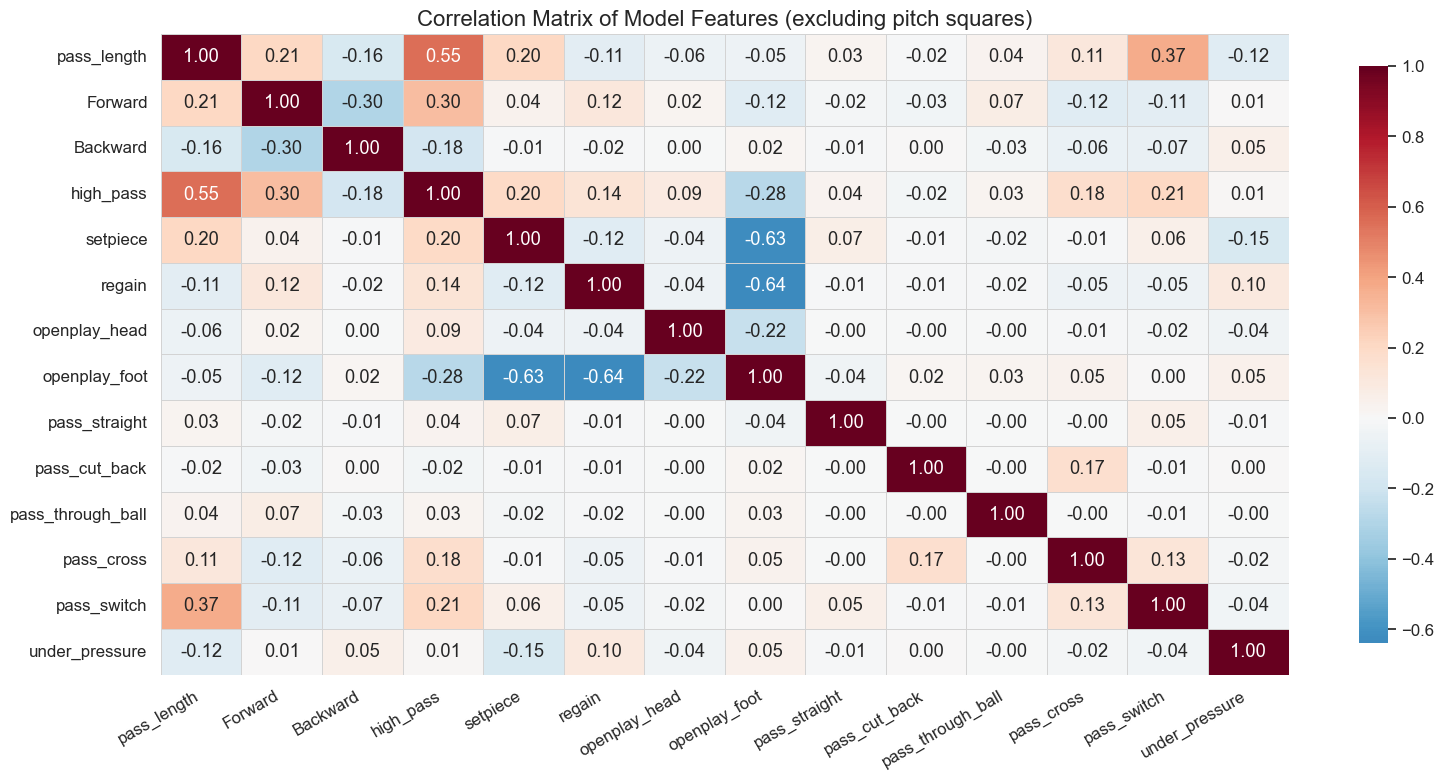

In [298]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only features that do NOT start with 'sq_'
features_no_sq = [f for f in FEATURES if not f.startswith("sq_")]

corr = X[features_no_sq].corr()

# Clean plotting style
sns.set_style("white")

plt.figure(figsize=(16,8))

sns.heatmap(
    corr,
    cmap="RdBu_r",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.4,
    linecolor="lightgray",
    cbar_kws={"shrink":0.9}
)

plt.title("Correlation Matrix of Model Features (excluding pitch squares)", fontsize=16)
plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## Train global xP model

In [296]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, brier_score_loss
import pandas as pd

# --------------------------------------------------
# Train / test split
# --------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=14
)

# --------------------------------------------------
# Fit expected pass completion model
# --------------------------------------------------

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [297]:
from sklearn.metrics import roc_auc_score, brier_score_loss

# -------------------------------
# Predictions and metrics
# -------------------------------

# Train set
y_train_pred_prob = model.predict_proba(X)[:, 1]
train_auc = roc_auc_score(y, y_train_pred_prob)
train_brier = brier_score_loss(y, y_train_pred_prob)

print("Train set:")
print("AUC:", train_auc)
print("Brier score:", train_brier)

# Test set
y_test_pred_prob = model.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, y_test_pred_prob)
test_brier = brier_score_loss(y_test, y_test_pred_prob)

print("\nTest set:")
print("AUC:", test_auc)
print("Brier score:", test_brier)

# -------------------------------
# Coefficient inspection
# -------------------------------

import pandas as pd

pd.set_option('display.max_rows', None)

coef_table = pd.DataFrame({
    "feature": FEATURES,
    "coef": model.coef_[0]
}).sort_values("coef")

# Remove pitch square features (they dominate the table)
coef_table_filtered = coef_table[~coef_table["feature"].str.startswith("sq_")]

print("\nCoefficients:")
display(coef_table_filtered)

Train set:
AUC: 0.864689839094243
Brier score: 0.11815557213106694

Test set:
AUC: 0.8645807511096637
Brier score: 0.11807075667870029

Coefficients:


,feature,coef
3,high_pass,-1.300366
13,under_pressure,-0.717858
6,openplay_head,-0.555499
10,pass_through_ball,-0.553673
12,pass_switch,-0.508365
1,Forward,-0.485794
11,pass_cross,-0.244614
0,pass_length,0.029720
5,regain,0.038080
8,pass_straight,0.045602


## Apply the xP model to Euros and Worlds final matches

In [30]:
matches_euros = sb.matches(competition_id=53, season_id=315) 
matches_worlds = sb.matches(competition_id=72, season_id=107)

In [31]:
final_euros = matches_euros[matches_euros['competition_stage'] == 'Final'].iloc[0] 
final_euros_id = final_euros['match_id']
events_final_euros = sb.events(match_id=final_euros_id)

In [32]:
final_world = matches_worlds[matches_worlds['competition_stage'] == 'Final'].iloc[0] 
final_world_id = final_world['match_id']
events_final_world = sb.events(match_id=final_world_id)

In [33]:
# Filter only passes

passes_final_euros = events_final_euros[events_final_euros['type'] == 'Pass'].copy()
passes_final_euros = passes_final_euros[passes_final_euros['pass_outcome'].ne("Injury Clearance")]

passes_final_world = events_final_world[events_final_world['type'] == 'Pass'].copy()
passes_final_world = passes_final_world[passes_final_world['pass_outcome'].ne("Injury Clearance")]

In [34]:
# Feature engineering for Euros final
df_euros_feat, X_euros, y_euros, FEATURES_euros, meta_euros = prepare_pass_features(passes_final_euros)

# Feature engineering for Worlds final
df_world_feat, X_world, y_world, FEATURES_world, meta_world = prepare_pass_features(passes_final_world)

In [35]:
meta_euros.columns

Index(['match_id', 'team', 'player'], dtype='object')

In [36]:
def aggregate_xP(df_feat, X, meta, model):
    df = df_feat.copy()
    X_use = X.copy()

    # Align features with model
    model_features = model.feature_names_in_
    for col in model_features:
        if col not in X_use.columns:
            X_use[col] = 0
    X_use = X_use[model_features]

    # Predict xP per pass
    df["xP"] = model.predict_proba(X_use)[:, 1]

    # Attach metadata without duplicating columns
    meta_use = meta.loc[:, ~meta.columns.isin(df.columns)]
    df = pd.concat(
        [df.reset_index(drop=True), meta_use.reset_index(drop=True)],
        axis=1
    )

    # Team-level aggregation
    team_stats = (
        df.groupby("team")
        .agg(
            total_passes=("completed", "count"),
            completed_passes=("completed", "sum"),
            total_xP=("xP", "sum"),
        )
        .reset_index()
    )
    team_stats["completion_rate_basic"] = team_stats["completed_passes"] / team_stats["total_passes"]
    team_stats["diff"] = team_stats["completed_passes"] - team_stats["total_xP"]
    team_stats["diff%"] = (team_stats["completed_passes"] - team_stats["total_xP"])/team_stats["total_passes"]

    # Player-level aggregation (keep country)
    player_stats = (
        df.groupby(["player", "team"])
        .agg(
            total_passes=("completed", "count"),
            completed_passes=("completed", "sum"),
            total_xP=("xP", "sum"),
        )
        .reset_index()
    )
    player_stats["completion_rate_basic"] = player_stats["completed_passes"] / player_stats["total_passes"]
    player_stats["diff"] = player_stats["completed_passes"] - player_stats["total_xP"]
    player_stats["diff%"] = (player_stats["completed_passes"] - player_stats["total_xP"])/player_stats["total_passes"]

    return {
        "team": team_stats,
        "player": player_stats
    }

In [37]:
euros_results = aggregate_xP(df_euros_feat, X_euros, meta_euros, model)
world_results = aggregate_xP(df_world_feat, X_world, meta_world, model)

team_euros = euros_results["team"]
player_euros = euros_results["player"]

team_world = world_results["team"]
player_world = world_results["player"]

In [38]:
team_euros

,team,total_passes,completed_passes,total_xP,completion_rate_basic,diff,diff%
0,England Women's,473,341,339.867335,0.720930,1.132665,0.002395
1,Spain Women's,832,699,647.834113,0.840144,51.165887,0.061497


In [39]:
player_euros

,player,team,total_passes,completed_passes,total_xP,completion_rate_basic,diff,diff%
0,Aitana Bonmati Conca,Spain Women's,86,73,68.078933,0.848837,4.921067,0.057222
1,Alessia Russo,England Women's,8,4,6.217734,0.500000,-2.217734,-0.277217
2,Alex Greenwood,England Women's,51,42,39.216904,0.823529,2.783096,0.054571
3,Alexia Putellas Segura,Spain Women's,49,39,36.620791,0.795918,2.379209,0.048555
4,Athenea del Castillo Belvide,Spain Women's,29,19,19.161704,0.655172,-0.161704,-0.005576
5,Bethany Mead,England Women's,5,5,4.298112,1.000000,0.701888,0.140378
6,Catalina Thomas Coll Lluch,Spain Women's,32,26,24.733071,0.812500,1.266929,0.039592
7,Chloe Kelly,England Women's,18,11,11.424468,0.611111,-0.424468,-0.023582
8,Claudia Pina Medina,Spain Women's,33,20,21.121549,0.606061,-1.121549,-0.033986
9,Ella Toone,England Women's,21,18,18.071000,0.857143,-0.071000,-0.003381


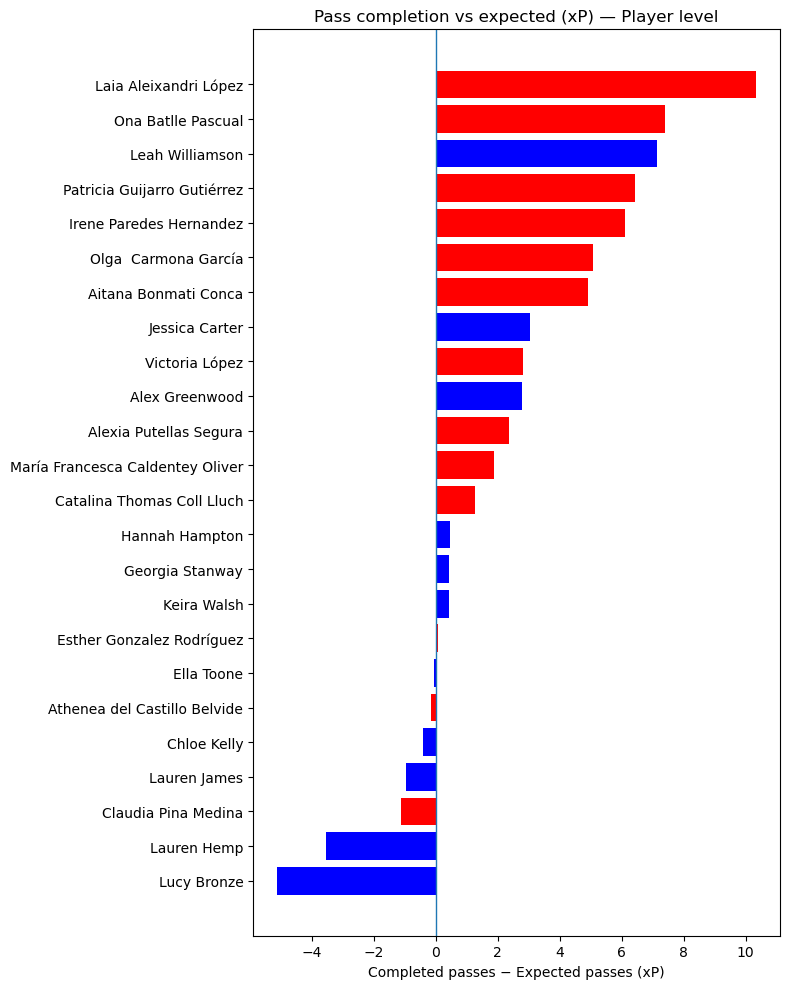

In [40]:
import matplotlib.pyplot as plt

df_plot = player_euros.copy()

# Optional: filter out very low volume players
df_plot = df_plot[df_plot["total_passes"] >= 10]

# Sort by difference
df_plot = df_plot.sort_values("diff")

# Team → colour mapping
team_colors = {
    "Spain Women's": "red",
    "England Women's": "blue",
}

colors = df_plot["team"].map(team_colors).fillna("grey")

plt.figure(figsize=(8, 10))
plt.barh(df_plot["player"], df_plot["diff"], color=colors)
plt.axvline(0, linewidth=1)

plt.xlabel("Completed passes − Expected passes (xP)")
plt.title("Pass completion vs expected (xP) — Player level")

plt.tight_layout()
plt.show()

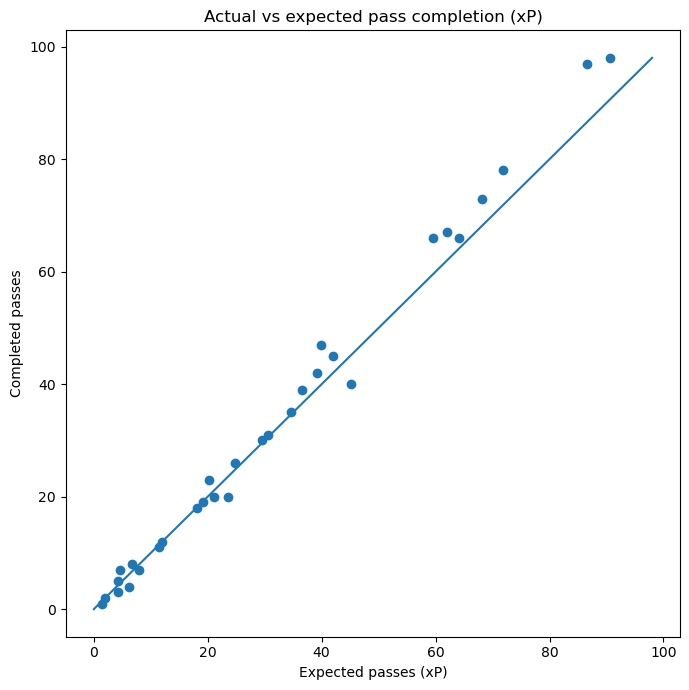

In [41]:
plt.figure(figsize=(7, 7))

plt.scatter(
    player_euros["total_xP"],
    player_euros["completed_passes"]
)

max_val = max(
    player_euros["total_xP"].max(),
    player_euros["completed_passes"].max()
)

plt.plot([0, max_val], [0, max_val])

plt.xlabel("Expected passes (xP)")
plt.ylabel("Completed passes")
plt.title("Actual vs expected pass completion (xP)")

plt.tight_layout()
plt.show()

In [42]:
team_world

,team,total_passes,completed_passes,total_xP,completion_rate_basic,diff,diff%
0,England Women's,408,293,291.570221,0.718137,1.429779,0.003504
1,Spain Women's,519,421,389.699737,0.811175,31.300263,0.060309


In [43]:
player_world

,player,team,total_passes,completed_passes,total_xP,completion_rate_basic,diff,diff%
0,Aitana Bonmati Conca,Spain Women's,45,41,34.484296,0.911111,6.515704,0.144793
1,Alba María Redondo Ferrer,Spain Women's,12,7,9.459676,0.583333,-2.459676,-0.204973
2,Alessia Russo,England Women's,12,5,8.024988,0.416667,-3.024988,-0.252082
3,Alex Greenwood,England Women's,54,40,40.935199,0.740741,-0.935199,-0.017318
4,Alexia Putellas Segura,Spain Women's,8,5,5.881144,0.625000,-0.881144,-0.110143
5,Bethany England,England Women's,4,3,3.195171,0.750000,-0.195171,-0.048793
6,Catalina Thomas Coll Lluch,Spain Women's,23,17,16.822926,0.739130,0.177074,0.007699
7,Chloe Kelly,England Women's,21,9,15.269526,0.428571,-6.269526,-0.298549
8,Ella Toone,England Women's,21,19,17.619939,0.904762,1.380061,0.065717
9,Georgia Stanway,England Women's,30,21,22.562275,0.700000,-1.562275,-0.052076


## Combined plots

In [44]:
df_euros_plot = player_euros.copy()
df_euros_plot["final"] = "Euros"

df_world_plot = player_world.copy()
df_world_plot["final"] = "World Cup"

df_plot = pd.concat([df_euros_plot, df_world_plot], ignore_index=True)

# Optional: filter low-volume performances
df_plot = df_plot[df_plot["total_passes"] >= 10]

In [45]:
df_plot = df_plot.sort_values(
    ["player", "final"],
    ascending=[True, False]  # World Cup first, Euros second
)

In [46]:
df_plot["total_passes_both_finals"] = (
    df_plot.groupby("player")["total_passes"]
    .transform("sum")
)

In [47]:
df_plot.head()

,player,team,total_passes,completed_passes,total_xP,completion_rate_basic,diff,diff%,final,total_passes_both_finals
31,Aitana Bonmati Conca,Spain Women's,45,41,34.484296,0.911111,6.515704,0.144793,World Cup,131
0,Aitana Bonmati Conca,Spain Women's,86,73,68.078933,0.848837,4.921067,0.057222,Euros,131
32,Alba María Redondo Ferrer,Spain Women's,12,7,9.459676,0.583333,-2.459676,-0.204973,World Cup,12
33,Alessia Russo,England Women's,12,5,8.024988,0.416667,-3.024988,-0.252082,World Cup,12
34,Alex Greenwood,England Women's,54,40,40.935199,0.740741,-0.935199,-0.017318,World Cup,105


In [48]:
team_colors = {
    "Spain Women's": "lightcoral",
    "England Women's": "royalblue",
}

df_plot["color"] = df_plot["team"].map(team_colors).fillna("grey")


In [49]:
import numpy as np
import matplotlib.pyplot as plt

# Order players by average diff (nice narrative ordering)
player_order = (
    df_plot.groupby("player")["diff"]
    .mean()
    .sort_values()
    .index
)

y_base = np.arange(len(player_order))

# Map player → y position
y_map = dict(zip(player_order, y_base))

# Offsets for the two finals
offset = 0.18
df_plot["y"] = df_plot["player"].map(y_map)
df_plot["y_plot"] = np.where(
    df_plot["final"] == "World Cup",
    df_plot["y"] + offset,
    df_plot["y"] - offset,
)


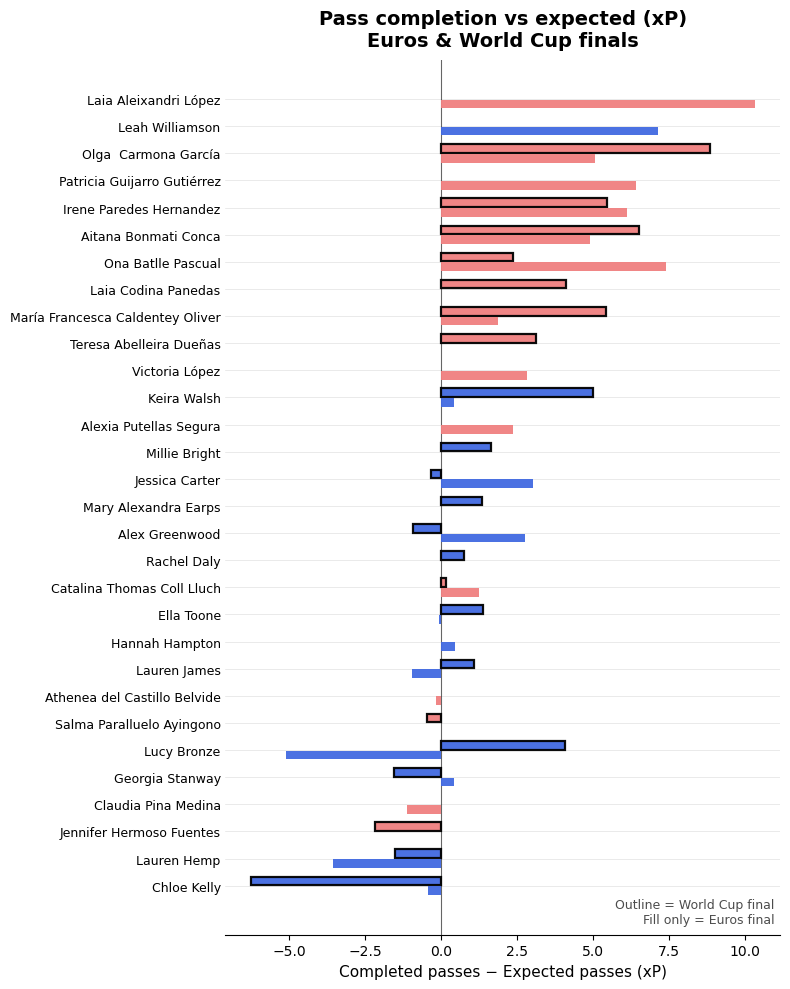

In [50]:
import matplotlib.pyplot as plt
import re

# Copy and filter
df_plot = df_plot.copy()
df_plot = df_plot[df_plot["total_passes_both_finals"] >= 15]

# Clean player names (remove trailing dash variants)
df_plot["player_clean"] = df_plot["player"].apply(
    lambda x: re.sub(r"[\s\-–—]+$", "", x)
)

# Order players by mean diff across finals
player_order = (
    df_plot.groupby("player_clean")["diff"]
    .mean()
    .sort_values()
    .index
    .tolist()
)

# Assign base y positions (one per player)
y_base = {p: i for i, p in enumerate(player_order)}

# Offset Euros / World Cup slightly
offset = {
    "Euros": -0.18,
    "World Cup": 0.18,
}

df_plot["y_plot"] = df_plot.apply(
    lambda r: y_base[r["player_clean"]] + offset[r["final"]],
    axis=1,
)

# ---- Plot ----
fig, ax = plt.subplots(figsize=(8, 10))

for _, r in df_plot.iterrows():
    ax.barh(
        y=r["y_plot"],
        width=r["diff"],
        height=0.32,
        color=r["color"],
        edgecolor="black" if r["final"] == "World Cup" else "none",
        linewidth=1.6 if r["final"] == "World Cup" else 0,
        alpha=0.95,
        zorder=3,
    )

# Zero reference line
ax.axvline(0, color="black", linewidth=0.8, alpha=0.6, zorder=2)

# Y-axis labels (players only once)
ax.set_yticks(list(y_base.values()))
ax.set_yticklabels(player_order, fontsize=9)

# Horizontal notebook-style guides
for y in y_base.values():
    ax.axhline(
        y=y,
        color="black",
        linewidth=0.4,
        alpha=0.15,
        zorder=1,
    )

# Labels & title
ax.set_xlabel("Completed passes − Expected passes (xP)", fontsize=11)
ax.set_title(
    "Pass completion vs expected (xP)\nEuros & World Cup finals",
    fontsize=14,
    weight="bold",
    pad=10,
)

# Minimal styling
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.tick_params(axis="x", labelsize=10)
ax.tick_params(axis="y", length=0)

# Legend note
ax.text(
    0.99, 0.01,
    "Outline = World Cup final\nFill only = Euros final",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=9,
    alpha=0.7,
)

plt.tight_layout()

plt.savefig("passcompletion.png", dpi=300, bbox_inches="tight")

plt.show()

### Update 14/02/2026: Download all datasets for future work.

In [56]:
import os
import joblib
import pandas as pd

SAVE_PATH = "Datasets/xP_master"
os.makedirs(SAVE_PATH, exist_ok=True)

def save_both(df, name, index=False):
    df.to_parquet(f"{SAVE_PATH}/{name}.parquet", index=index)
    df.to_csv(f"{SAVE_PATH}/{name}.csv", index=index)
    print(f"✔ saved {name}")

# Core datasets
save_both(women_comps, "competitions")
save_both(matches_df, "matches")
save_both(passes_df, "passes_raw")

# Feature datasets + xP
save_both(df, "passes_features_with_xp")
save_both(X, "model_features_X")
save_both(y.to_frame("completed"), "model_target_y")
save_both(meta, "meta")

# Feature names
with open(f"{SAVE_PATH}/feature_names.txt", "w") as f:
    for feat in FEATURES:
        f.write(feat + "\n")
print("✔ feature names saved")

# Model
joblib.dump(model, f"{SAVE_PATH}/xp_model.pkl")
print("✔ model saved")

# Euros results
save_both(df_euros_feat, "euros_passes")
save_both(team_euros, "euros_team")
save_both(player_euros, "euros_player")

# World Cup results
save_both(df_world_feat, "world_passes")
save_both(team_world, "world_team")
save_both(player_world, "world_player")

# Coefficient table
save_both(coef_table, "xp_model_coef_table")

print("✅ EVERYTHING SAVED SUCCESSFULLY (PARQUET + CSV)")

✔ saved competitions
✔ saved matches
✔ saved passes_raw
✔ saved passes_features_with_xp
✔ saved model_features_X


AttributeError: 'int' object has no attribute 'to_frame'